In [1]:
import pandas as pd
from glob import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

## Multiple performance records

In [2]:
fpaths_performance_records= glob(os.path.join('data', 'performanceRecords*.json')) 
print(len(fpaths_performance_records))

400


In [3]:
def load_performance_record(fpath: str) -> pd.DataFrame:
    """ Load a performance record.
    Returns a DataFrame.

    ----
    Performance Record (05/01/2025)
    { 
        records: [],
        nRecords: int,
        experimentTag: str,
        batchTimestamp: int,
        iteration: int
    }
    
    """
    df_i = pd.read_json(fpath)
    df_i_a = df_i.merge(df_i.records.apply(pd.Series),left_index=True,right_index=True)
    df_i_b = df_i_a.merge(
        df_i_a.detail.apply(pd.Series),
        left_index=True, right_index=True
    )
    df_i_c = df_i_b.drop(['records','detail'],axis=1)
    return df_i_c
    
    
dfs = []
for i,fpath in enumerate(sorted(fpaths_performance_records)):
    try:
        dfs.append(load_performance_record(fpath))
    except Exception as e:
        print(f'Error occurred for [{i}] {fpath}: ', e)
    

In [4]:
def preprocess_dfc(dfc: pd.DataFrame) -> pd.DataFrame:
    dfc = dfc.drop(['entryType', 'duration'], axis=1)
    dfc['step'] = dfc['name'].apply(lambda x: '_'.join(x.split('_')[1:]))
    dfc['stepType'] = dfc['name'].apply(lambda x: x.split('_')[0])
    dfc = dfc.drop(['name'],axis=1)
    return dfc

Node Performance Docs: <https://nodejs.org/api/perf_hooks.htm>

- `performanceEntry.startTime`: The high resolution millisecond timestamp marking the starting time of the Performance Entry.



In [5]:
# create dfc
dfc = pd.concat(
    (load_performance_record(fpath) for fpath in fpaths_performance_records),
    axis = 0
)
# preprocess
dfc = preprocess_dfc(dfc)
display(dfc.head())
print(dfc.shape)

,nRecords,experimentTag,iteration,batchTimestamp,startTime,implementation,step,stepType
0,8,bbs-bls-signature-2020-31,31,1736898157,51672.226209,BbsBlsSignature2020,SIGN_VC,START
1,8,bbs-bls-signature-2020-31,31,1736898157,51690.122750,BbsBlsSignature2020,SIGN_VC,END
2,8,bbs-bls-signature-2020-31,31,1736898157,51690.136209,BbsBlsSignature2020,VERIFY_VC,START
3,8,bbs-bls-signature-2020-31,31,1736898157,51720.963917,BbsBlsSignature2020,VERIFY_VC,END
4,8,bbs-bls-signature-2020-31,31,1736898157,51721.086584,BbsBlsSignature2020,DERIVE,START


(2800, 8)


In [6]:
dfc.step.value_counts(dropna=False)

step
SIGN_VC           800
VERIFY_VC         800
DERIVE            600
VERIFY_DERIVED    600
Name: count, dtype: int64

In [11]:
dfc.sort_values(['experimentTag','iteration']).head(3)

,nRecords,experimentTag,iteration,batchTimestamp,startTime,implementation,step,stepType
0,8,bbs-bls-signature-2020-0,0,1736898157,47322.304125,BbsBlsSignature2020,SIGN_VC,START
1,8,bbs-bls-signature-2020-0,0,1736898157,47365.146584,BbsBlsSignature2020,SIGN_VC,END
2,8,bbs-bls-signature-2020-0,0,1736898157,47365.163917,BbsBlsSignature2020,VERIFY_VC,START


In [12]:
dfc.groupby(['implementation', 'iteration']).size()

implementation             iteration
BbsBlsSignature2020        0            8
                           1            8
                           2            8
                           3            8
                           4            8
                                       ..
ecdsa-sd-2023-cryptosuite  95           8
                           96           8
                           97           8
                           98           8
                           99           8
Length: 400, dtype: int64

`dfc_x`

In [13]:
dfc_x = dfc.set_index(['implementation', 'iteration','step','stepType'])
dfc_x.head()

nRecords  \
implementation      iteration step      stepType             
BbsBlsSignature2020 31        SIGN_VC   START            8   
                                        END              8   
                              VERIFY_VC START            8   
                                        END              8   
                              DERIVE    START            8   

                                                              experimentTag  \
implementation      iteration step      stepType                              
BbsBlsSignature2020 31        SIGN_VC   START     bbs-bls-signature-2020-31   
                                        END       bbs-bls-signature-2020-31   
                              VERIFY_VC START     bbs-bls-signature-2020-31   
                                        END       bbs-bls-signature-2020-31   
                              DERIVE    START     bbs-bls-signature-2020-31   

                                                  batchTimestamp     startTime  
implementation      iteration step      stepType                                
BbsBlsSignature2020 31        SIGN_VC   START         1736898157  51672.226209  
                                        END           1736898157  51690.122750  
                              VERIFY_VC START         1736898157  51690.136209  
                                        END           1736898157  51720.963917  
                              DERIVE    START         1736898157  51721.086584

----

`a`: the DataFrame containing the preprocessed performance records.

In [14]:
# Unstack: turn START and END to columns
a = dfc_x['startTime'].unstack('stepType')
# Compute delta time
a['delta'] = a.apply(lambda r: r.END - r.START, axis=1)
# Now, START and END columns are no longer needed.
a.drop(['START','END'], axis=1, inplace=True)
a

stepType                                                delta
implementation            iteration step                     
BbsBlsSignature2020       0         DERIVE          65.583333
                                    SIGN_VC         42.842459
                                    VERIFY_DERIVED  34.665792
                                    VERIFY_VC       40.145125
                          1         DERIVE          60.160417
...                                                       ...
ecdsa-sd-2023-cryptosuite 98        VERIFY_VC        1.652167
                          99        DERIVE           1.877292
                                    SIGN_VC          1.616625
                                    VERIFY_DERIVED   1.611208
                                    VERIFY_VC        1.412500

[1400 rows x 1 columns]

`b`: the DataFrame containing descriptive statistics from the performance records in DataFrame `a`.

In [15]:
b = a.copy()
b.reset_index(inplace=True)
b = b.groupby(['implementation','step'])['delta'].agg(['mean','std', 'var','min','max','count'])
b

mean        std         var  \
implementation              step                                                
BbsBlsSignature2020         DERIVE           55.361303   3.653953   13.351375   
                            SIGN_VC          16.850021   2.858039    8.168387   
                            VERIFY_DERIVED   30.065914   0.927334    0.859948   
                            VERIFY_VC        31.770128   1.858821    3.455215   
Ed25519Signature2020        SIGN_VC           1.234450   0.377805    0.142737   
                            VERIFY_VC         1.138885   0.415222    0.172409   
bbs-termwise-signature-2023 DERIVE          208.785715   7.091448   50.288634   
                            SIGN_VC          74.059173  13.527551  182.994640   
                            VERIFY_DERIVED   97.472273   3.919794   15.364784   
                            VERIFY_VC        84.284133   3.329219   11.083702   
ecdsa-sd-2023-cryptosuite   DERIVE            1.658159   0.159246    0.025359   
                            SIGN_VC           1.907138   0.429486    0.184458   
                            VERIFY_DERIVED    1.959488   0.702581    0.493620   
                            VERIFY_VC         1.647698   0.345393    0.119297   

                                                   min         max  count  
implementation              step                                           
BbsBlsSignature2020         DERIVE           52.484334   84.098958    100  
                            SIGN_VC          15.286875   42.842459    100  
                            VERIFY_DERIVED   29.018625   34.665792    100  
                            VERIFY_VC        30.492167   41.344875    100  
Ed25519Signature2020        SIGN_VC           0.963125    4.447458    100  
                            VERIFY_VC         0.823167    3.304625    100  
bbs-termwise-signature-2023 DERIVE          203.435791  252.760833    100  
                            SIGN_VC          68.569208  199.929833    100  
                            VERIFY_DERIVED   95.043042  128.161791    100  
                            VERIFY_VC        80.567084  106.405541    100  
ecdsa-sd-2023-cryptosuite   DERIVE            1.388542    2.480583    100  
                            SIGN_VC           1.484542    5.467291    100  
                            VERIFY_DERIVED    1.246167    3.522125    100  
                            VERIFY_VC         1.332166    4.390291    100

`c`: DataFrame focussing on the mean execution time per step, for each crypto suite implementation.

In [21]:
c = b.copy()
c = c['mean'].unstack('step').T
c

implementation,BbsBlsSignature2020,Ed25519Signature2020,bbs-termwise-signature-2023,ecdsa-sd-2023-cryptosuite
step,,,,
DERIVE,55.361303,NaN,208.785715,1.658159
SIGN_VC,16.850021,1.234450,74.059173,1.907138
VERIFY_DERIVED,30.065914,NaN,97.472273,1.959488
VERIFY_VC,31.770128,1.138885,84.284133,1.647698


Seaborn

In [22]:
# df seaborn
dfsb = a.reset_index()
print(dfsb.shape)
#display(dfsb.head())

(1400, 4)


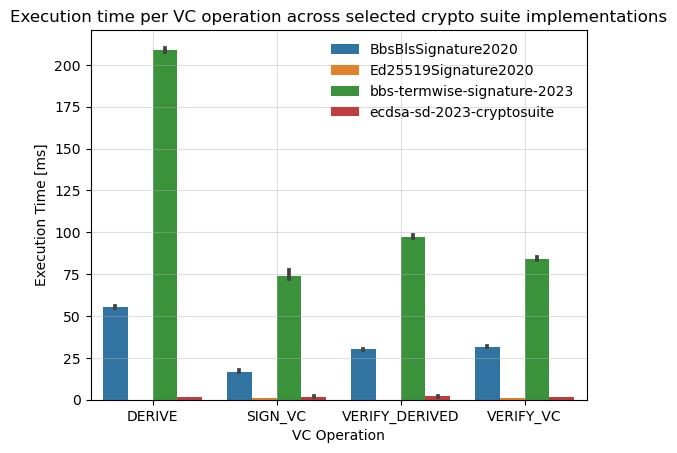

In [24]:
ax = sns.barplot(
    data = dfsb,
    x = 'step',
    hue = 'implementation',
    y = 'delta')

ax.legend(frameon=False)
ax.set_title('Execution time per VC operation across selected crypto suite implementations')
ax.set_xlabel('VC Operation')
ax.set_ylabel('Execution Time [ms]')
ax.grid(alpha=.4)
plt.show()

In [32]:
x = dfsb.groupby(['implementation', 'step'])['delta'].agg(['mean'])
x.unstack('implementation')

mean                       \
implementation BbsBlsSignature2020 Ed25519Signature2020   
step                                                      
DERIVE                   55.361303                  NaN   
SIGN_VC                  16.850021             1.234450   
VERIFY_DERIVED           30.065914                  NaN   
VERIFY_VC                31.770128             1.138885   

                                                                      
implementation bbs-termwise-signature-2023 ecdsa-sd-2023-cryptosuite  
step                                                                  
DERIVE                          208.785715                  1.658159  
SIGN_VC                          74.059173                  1.907138  
VERIFY_DERIVED                   97.472273                  1.959488  
VERIFY_VC                        84.284133                  1.647698